## Import Library

In [1]:
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

## Mengatur Lokasi Folder

In [2]:
direktori_aktif = Path.cwd().resolve()

if direktori_aktif.name == "notebooks":
    direktori_project = direktori_aktif.parent
else:
    direktori_project = direktori_aktif

direktori_data_processed = direktori_project / "data" / "processed"
direktori_models = direktori_project / "models"
direktori_output = direktori_project / "reports" / "outputs"
direktori_gambar = direktori_project / "reports" / "figures"

direktori_models.mkdir(parents=True, exist_ok=True)
direktori_output.mkdir(parents=True, exist_ok=True)
direktori_gambar.mkdir(parents=True, exist_ok=True)

print("Direktori project:", direktori_project)
print("Folder data processed:", direktori_data_processed)
print("Folder models:", direktori_models)
print("Folder output:", direktori_output)
print("Folder gambar:", direktori_gambar)

Direktori project: C:\Users\ASUS\PHISHING
Folder data processed: C:\Users\ASUS\PHISHING\data\processed
Folder models: C:\Users\ASUS\PHISHING\models
Folder output: C:\Users\ASUS\PHISHING\reports\outputs
Folder gambar: C:\Users\ASUS\PHISHING\reports\figures


## Load Data Hasil Pra-Proses

In [3]:
X_train = pd.read_csv(direktori_data_processed / "X_train.csv")
X_test = pd.read_csv(direktori_data_processed / "X_test.csv")

X_train_scaled = pd.read_csv(direktori_data_processed / "X_train_scaled.csv")
X_test_scaled = pd.read_csv(direktori_data_processed / "X_test_scaled.csv")

y_train = pd.read_csv(direktori_data_processed / "y_train.csv")["target_phishing"]
y_test = pd.read_csv(direktori_data_processed / "y_test.csv")["target_phishing"]

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran X_train_scaled:", X_train_scaled.shape)
print("Ukuran X_test_scaled:", X_test_scaled.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (188636, 71)
Ukuran X_test: (47159, 71)
Ukuran X_train_scaled: (188636, 71)
Ukuran X_test_scaled: (47159, 71)
Ukuran y_train: (188636,)
Ukuran y_test: (47159,)


## Validasi Data Modeling

In [4]:
if list(X_train.columns) != list(X_test.columns):
    raise ValueError("Kolom X_train dan X_test tidak sama.")

if list(X_train_scaled.columns) != list(X_test_scaled.columns):
    raise ValueError("Kolom X_train_scaled dan X_test_scaled tidak sama.")

if X_train.isna().sum().sum() > 0:
    raise ValueError("X_train masih memiliki missing value.")

if X_test.isna().sum().sum() > 0:
    raise ValueError("X_test masih memiliki missing value.")

print("Data modeling sudah valid.")
print("Jumlah fitur:", X_train.shape[1])
print("Distribusi target train:")
print(y_train.value_counts().sort_index())
print()
print("Distribusi target test:")
print(y_test.value_counts().sort_index())

Data modeling sudah valid.
Jumlah fitur: 71
Distribusi target train:
target_phishing
0    107880
1     80756
Name: count, dtype: int64

Distribusi target test:
target_phishing
0    26970
1    20189
Name: count, dtype: int64


## Fungsi Evaluasi Model

In [7]:
def evaluasi_model(nama_model, model, X_uji, y_uji):
    prediksi = model.predict(X_uji)
    
    if hasattr(model, "predict_proba"):
        probabilitas_phishing = model.predict_proba(X_uji)[:, 1]
        roc_auc = roc_auc_score(y_uji, probabilitas_phishing)
    else:
        probabilitas_phishing = None
        roc_auc = np.nan
    
    hasil = {
        "nama_model": nama_model,
        "accuracy": accuracy_score(y_uji, prediksi),
        "precision_phishing": precision_score(y_uji, prediksi, pos_label=1),
        "recall_phishing": recall_score(y_uji, prediksi, pos_label=1),
        "f1_phishing": f1_score(y_uji, prediksi, pos_label=1),
        "roc_auc": roc_auc
    }
    
    matriks = confusion_matrix(y_uji, prediksi)
    laporan = classification_report(
        y_uji,
        prediksi,
        target_names=["Legitimate", "Phishing"]
    )
    
    return hasil, matriks, laporan

## Fungsi Menyimpan Confusion Matrix

In [8]:
def simpan_confusion_matrix(nama_model, matriks):
    plt.figure(figsize=(6, 5))
    plt.imshow(matriks)
    plt.title(f"Confusion Matrix - {nama_model}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.xticks([0, 1], ["Legitimate", "Phishing"])
    plt.yticks([0, 1], ["Legitimate", "Phishing"])
    
    for baris in range(matriks.shape[0]):
        for kolom in range(matriks.shape[1]):
            plt.text(
                kolom,
                baris,
                matriks[baris, kolom],
                ha="center",
                va="center"
            )
    
    plt.tight_layout()
    
    nama_file = nama_model.lower().replace(" ", "_") + "_confusion_matrix.png"
    lokasi_gambar = direktori_gambar / nama_file
    
    plt.savefig(lokasi_gambar, dpi=300)
    plt.show()
    
    print("Confusion matrix disimpan di:", lokasi_gambar)

## Model 1: Logistic Regression

Evaluasi Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     26970
    Phishing       1.00      1.00      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



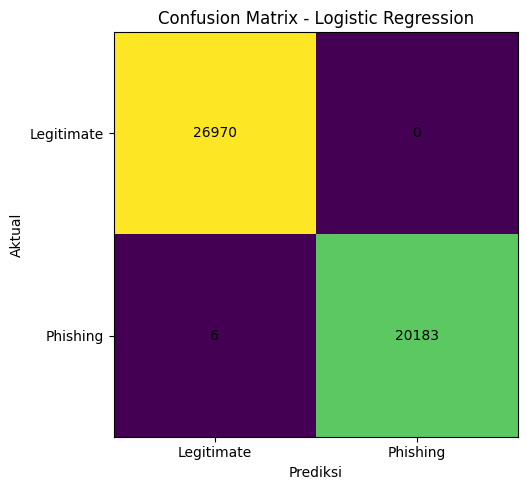

Confusion matrix disimpan di: C:\Users\ASUS\PHISHING\reports\figures\logistic_regression_confusion_matrix.png


In [9]:
model_logistic_regression = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_logistic_regression.fit(X_train_scaled, y_train)

hasil_logistic, matriks_logistic, laporan_logistic = evaluasi_model(
    "Logistic Regression",
    model_logistic_regression,
    X_test_scaled,
    y_test
)

print("Evaluasi Logistic Regression")
print(laporan_logistic)
simpan_confusion_matrix("Logistic Regression", matriks_logistic)

## Model 2: Random Forest

Evaluasi Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     26970
    Phishing       1.00      1.00      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



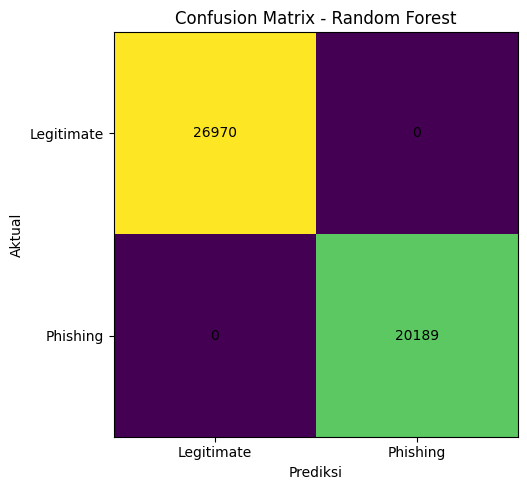

Confusion matrix disimpan di: C:\Users\ASUS\PHISHING\reports\figures\random_forest_confusion_matrix.png


In [10]:
model_random_forest = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_random_forest.fit(X_train, y_train)

hasil_random_forest, matriks_random_forest, laporan_random_forest = evaluasi_model(
    "Random Forest",
    model_random_forest,
    X_test,
    y_test
)

print("Evaluasi Random Forest")
print(laporan_random_forest)
simpan_confusion_matrix("Random Forest", matriks_random_forest)

## Model 3: XGBoost

Evaluasi XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     26970
    Phishing       1.00      1.00      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



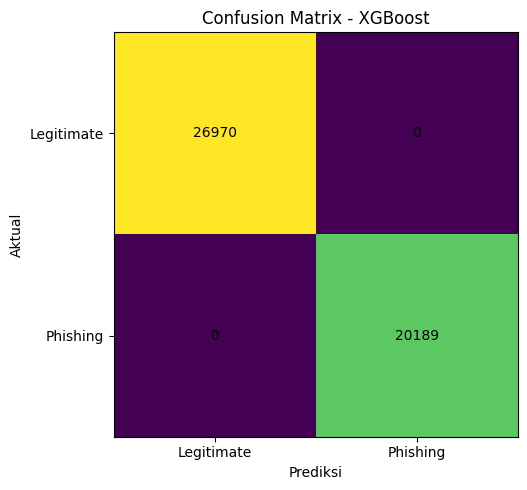

Confusion matrix disimpan di: C:\Users\ASUS\PHISHING\reports\figures\xgboost_confusion_matrix.png


In [11]:
jumlah_legitimate = (y_train == 0).sum()
jumlah_phishing = (y_train == 1).sum()
bobot_phishing = jumlah_legitimate / jumlah_phishing

model_xgboost = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=bobot_phishing,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model_xgboost.fit(X_train, y_train)

hasil_xgboost, matriks_xgboost, laporan_xgboost = evaluasi_model(
    "XGBoost",
    model_xgboost,
    X_test,
    y_test
)

print("Evaluasi XGBoost")
print(laporan_xgboost)
simpan_confusion_matrix("XGBoost", matriks_xgboost)

## Membandingkan Semua Model

In [12]:
daftar_hasil_model = [
    hasil_logistic,
    hasil_random_forest,
    hasil_xgboost
]

hasil_evaluasi_model = pd.DataFrame(daftar_hasil_model)

kolom_metrik = [
    "accuracy",
    "precision_phishing",
    "recall_phishing",
    "f1_phishing",
    "roc_auc"
]

hasil_evaluasi_model[kolom_metrik] = hasil_evaluasi_model[kolom_metrik].round(4)

hasil_evaluasi_model = hasil_evaluasi_model.sort_values(
    by=["f1_phishing", "recall_phishing", "roc_auc"],
    ascending=False
)

hasil_evaluasi_model

,nama_model,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc
1,Random Forest,1.0000,1.0,1.0000,1.0000,1.0
2,XGBoost,1.0000,1.0,1.0000,1.0000,1.0
0,Logistic Regression,0.9999,1.0,0.9997,0.9999,1.0


## Menyimpan Hasil Evaluasi

In [13]:
lokasi_hasil_evaluasi = direktori_output / "hasil_evaluasi_model_baseline.csv"

hasil_evaluasi_model.to_csv(lokasi_hasil_evaluasi, index=False)

print("Hasil evaluasi model baseline disimpan di:")
print(lokasi_hasil_evaluasi)

Hasil evaluasi model baseline disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\hasil_evaluasi_model_baseline.csv


## Menyimpan Classification Report

In [14]:
daftar_laporan_model = {
    "logistic_regression": laporan_logistic,
    "random_forest": laporan_random_forest,
    "xgboost": laporan_xgboost
}

for nama_file, isi_laporan in daftar_laporan_model.items():
    lokasi_laporan = direktori_output / f"classification_report_{nama_file}.txt"
    
    with open(lokasi_laporan, "w", encoding="utf-8") as file:
        file.write(isi_laporan)
    
    print("Laporan disimpan:", lokasi_laporan)

Laporan disimpan: C:\Users\ASUS\PHISHING\reports\outputs\classification_report_logistic_regression.txt
Laporan disimpan: C:\Users\ASUS\PHISHING\reports\outputs\classification_report_random_forest.txt
Laporan disimpan: C:\Users\ASUS\PHISHING\reports\outputs\classification_report_xgboost.txt


## Menyimpan Model Baseline

In [15]:
lokasi_model_logistic = direktori_models / "model_logistic_regression.pkl"
lokasi_model_random_forest = direktori_models / "model_random_forest.pkl"
lokasi_model_xgboost = direktori_models / "model_xgboost.pkl"

joblib.dump(model_logistic_regression, lokasi_model_logistic)
joblib.dump(model_random_forest, lokasi_model_random_forest)
joblib.dump(model_xgboost, lokasi_model_xgboost)

print("Model Logistic Regression disimpan di:", lokasi_model_logistic)
print("Model Random Forest disimpan di:", lokasi_model_random_forest)
print("Model XGBoost disimpan di:", lokasi_model_xgboost)

Model Logistic Regression disimpan di: C:\Users\ASUS\PHISHING\models\model_logistic_regression.pkl
Model Random Forest disimpan di: C:\Users\ASUS\PHISHING\models\model_random_forest.pkl
Model XGBoost disimpan di: C:\Users\ASUS\PHISHING\models\model_xgboost.pkl


## Menentukan Kandidat Model Terbaik

In [16]:
nama_model_terbaik = hasil_evaluasi_model.iloc[0]["nama_model"]

if nama_model_terbaik == "Logistic Regression":
    model_terbaik_baseline = model_logistic_regression
    jenis_data_model_terbaik = "scaled"
elif nama_model_terbaik == "Random Forest":
    model_terbaik_baseline = model_random_forest
    jenis_data_model_terbaik = "tanpa_scaling"
else:
    model_terbaik_baseline = model_xgboost
    jenis_data_model_terbaik = "tanpa_scaling"

lokasi_model_terbaik_baseline = direktori_models / "model_terbaik_baseline.pkl"

joblib.dump(model_terbaik_baseline, lokasi_model_terbaik_baseline)

print("Kandidat model terbaik baseline:", nama_model_terbaik)
print("Jenis data yang digunakan:", jenis_data_model_terbaik)
print("Model terbaik baseline disimpan di:", lokasi_model_terbaik_baseline)

Kandidat model terbaik baseline: Random Forest
Jenis data yang digunakan: tanpa_scaling
Model terbaik baseline disimpan di: C:\Users\ASUS\PHISHING\models\model_terbaik_baseline.pkl


## Menyimpan Metadata Modeling

In [17]:
metadata_modeling = {
    "target": "target_phishing",
    "arti_target": {
        "1": "Phishing",
        "0": "Legitimate"
    },
    "jumlah_fitur": int(X_train.shape[1]),
    "jumlah_data_train": int(X_train.shape[0]),
    "jumlah_data_test": int(X_test.shape[0]),
    "model_yang_dilatih": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "model_terbaik_baseline": nama_model_terbaik,
    "jenis_data_model_terbaik": jenis_data_model_terbaik,
    "catatan": "Pemilihan model baseline berdasarkan f1_phishing, recall_phishing, dan roc_auc."
}

lokasi_metadata_modeling = direktori_output / "metadata_modeling_baseline.json"

with open(lokasi_metadata_modeling, "w", encoding="utf-8") as file:
    json.dump(metadata_modeling, file, indent=4, ensure_ascii=False)

print("Metadata modeling disimpan di:")
print(lokasi_metadata_modeling)

Metadata modeling disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\metadata_modeling_baseline.json


## Ringkasan Akhir

In [19]:
print("RINGKASAN MODELING BASELINE")
print("-" * 45)
print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test:", X_test.shape[0])
print("Jumlah fitur:", X_train.shape[1])
print()
print("Hasil evaluasi model:")
print(hasil_evaluasi_model)
print()
print("Kandidat model terbaik baseline:", nama_model_terbaik)
print("Jenis data model terbaik:", jenis_data_model_terbaik)
print()
print("File model tersimpan di:")
print(lokasi_model_logistic)
print(lokasi_model_random_forest)
print(lokasi_model_xgboost)
print(lokasi_model_terbaik_baseline)

RINGKASAN MODELING BASELINE
---------------------------------------------
Jumlah data train: 188636
Jumlah data test: 47159
Jumlah fitur: 71

Hasil evaluasi model:
            nama_model  accuracy  precision_phishing  recall_phishing  \
1        Random Forest    1.0000                 1.0           1.0000   
2              XGBoost    1.0000                 1.0           1.0000   
0  Logistic Regression    0.9999                 1.0           0.9997   

   f1_phishing  roc_auc  
1       1.0000      1.0  
2       1.0000      1.0  
0       0.9999      1.0  

Kandidat model terbaik baseline: Random Forest
Jenis data model terbaik: tanpa_scaling

File model tersimpan di:
C:\Users\ASUS\PHISHING\models\model_logistic_regression.pkl
C:\Users\ASUS\PHISHING\models\model_random_forest.pkl
C:\Users\ASUS\PHISHING\models\model_xgboost.pkl
C:\Users\ASUS\PHISHING\models\model_terbaik_baseline.pkl


## MODEL JELEK, LANJUT !

## Import Library

In [20]:
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

## Mengatur Lokasi Folder

In [21]:
direktori_aktif = Path.cwd().resolve()

if direktori_aktif.name == "notebooks":
    direktori_project = direktori_aktif.parent
else:
    direktori_project = direktori_aktif

direktori_data_processed = direktori_project / "data" / "processed"
direktori_models = direktori_project / "models"
direktori_output = direktori_project / "reports" / "outputs"
direktori_gambar = direktori_project / "reports" / "figures"

direktori_models.mkdir(parents=True, exist_ok=True)
direktori_output.mkdir(parents=True, exist_ok=True)
direktori_gambar.mkdir(parents=True, exist_ok=True)

print("Direktori project:", direktori_project)
print("Folder data processed:", direktori_data_processed)
print("Folder models:", direktori_models)
print("Folder output:", direktori_output)
print("Folder gambar:", direktori_gambar)

Direktori project: C:\Users\ASUS\PHISHING
Folder data processed: C:\Users\ASUS\PHISHING\data\processed
Folder models: C:\Users\ASUS\PHISHING\models
Folder output: C:\Users\ASUS\PHISHING\reports\outputs
Folder gambar: C:\Users\ASUS\PHISHING\reports\figures


## Load Data Hasil Pra-Proses

In [22]:
X_train = pd.read_csv(direktori_data_processed / "X_train.csv")
X_test = pd.read_csv(direktori_data_processed / "X_test.csv")

X_train_scaled = pd.read_csv(direktori_data_processed / "X_train_scaled.csv")
X_test_scaled = pd.read_csv(direktori_data_processed / "X_test_scaled.csv")

y_train = pd.read_csv(direktori_data_processed / "y_train.csv")["target_phishing"]
y_test = pd.read_csv(direktori_data_processed / "y_test.csv")["target_phishing"]

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran X_train_scaled:", X_train_scaled.shape)
print("Ukuran X_test_scaled:", X_test_scaled.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (188636, 71)
Ukuran X_test: (47159, 71)
Ukuran X_train_scaled: (188636, 71)
Ukuran X_test_scaled: (47159, 71)
Ukuran y_train: (188636,)
Ukuran y_test: (47159,)


## Load Model Baseline

In [23]:
model_logistic_regression = joblib.load(direktori_models / "model_logistic_regression.pkl")
model_random_forest = joblib.load(direktori_models / "model_random_forest.pkl")
model_xgboost = joblib.load(direktori_models / "model_xgboost.pkl")

print("Model baseline berhasil dimuat.")

Model baseline berhasil dimuat.


## Fungsi Evaluasi Model 

In [24]:
def evaluasi_model(nama_model, nama_skenario, model, X_uji, y_uji, jumlah_fitur):
    prediksi = model.predict(X_uji)

    if hasattr(model, "predict_proba"):
        probabilitas_phishing = model.predict_proba(X_uji)[:, 1]
        nilai_roc_auc = roc_auc_score(y_uji, probabilitas_phishing)
    else:
        nilai_roc_auc = np.nan

    hasil = {
        "nama_skenario": nama_skenario,
        "nama_model": nama_model,
        "jumlah_fitur": jumlah_fitur,
        "accuracy": accuracy_score(y_uji, prediksi),
        "precision_phishing": precision_score(y_uji, prediksi, pos_label=1),
        "recall_phishing": recall_score(y_uji, prediksi, pos_label=1),
        "f1_phishing": f1_score(y_uji, prediksi, pos_label=1),
        "roc_auc": nilai_roc_auc
    }

    matriks = confusion_matrix(y_uji, prediksi)

    laporan = classification_report(
        y_uji,
        prediksi,
        target_names=["Legitimate", "Phishing"]
    )

    return hasil, matriks, laporan

## Fungsi Menyimpan Confusion Matrix

In [25]:
def simpan_confusion_matrix(nama_file, judul, matriks):
    plt.figure(figsize=(6, 5))
    plt.imshow(matriks)
    plt.title(judul)
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.xticks([0, 1], ["Legitimate", "Phishing"])
    plt.yticks([0, 1], ["Legitimate", "Phishing"])

    for baris in range(matriks.shape[0]):
        for kolom in range(matriks.shape[1]):
            plt.text(
                kolom,
                baris,
                matriks[baris, kolom],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    lokasi_gambar = direktori_gambar / nama_file
    plt.savefig(lokasi_gambar, dpi=300)
    plt.show()

    print("Confusion matrix disimpan di:", lokasi_gambar)

## Evaluasi Ulang Model Baseline

In [26]:
hasil_logistic, matriks_logistic, laporan_logistic = evaluasi_model(
    "Logistic Regression",
    "Baseline Semua Fitur",
    model_logistic_regression,
    X_test_scaled,
    y_test,
    X_test_scaled.shape[1]
)

hasil_random_forest, matriks_random_forest, laporan_random_forest = evaluasi_model(
    "Random Forest",
    "Baseline Semua Fitur",
    model_random_forest,
    X_test,
    y_test,
    X_test.shape[1]
)

hasil_xgboost, matriks_xgboost, laporan_xgboost = evaluasi_model(
    "XGBoost",
    "Baseline Semua Fitur",
    model_xgboost,
    X_test,
    y_test,
    X_test.shape[1]
)

hasil_baseline = pd.DataFrame([
    hasil_logistic,
    hasil_random_forest,
    hasil_xgboost
])

hasil_baseline.round(4)

,nama_skenario,nama_model,jumlah_fitur,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc
0,Baseline Semua Fitur,Logistic Regression,71,0.9999,1.0,0.9997,0.9999,1.0
1,Baseline Semua Fitur,Random Forest,71,1.0000,1.0,1.0000,1.0000,1.0
2,Baseline Semua Fitur,XGBoost,71,1.0000,1.0,1.0000,1.0000,1.0


## Feature Importance Random Forest

In [27]:
importance_random_forest = pd.DataFrame({
    "fitur": X_train.columns,
    "importance": model_random_forest.feature_importances_
})

importance_random_forest = importance_random_forest.sort_values(
    by="importance",
    ascending=False
)

lokasi_importance_random_forest = direktori_output / "feature_importance_random_forest.csv"
importance_random_forest.to_csv(lokasi_importance_random_forest, index=False)

importance_random_forest.head(20)

,fitur,importance
3,URLSimilarityIndex,0.169314
49,NoOfExternalRef,0.151113
22,LineOfCode,0.150936
47,NoOfSelfRef,0.093061
44,NoOfImage,0.076646
36,HasSocialNet,0.046629
46,NoOfJS,0.036331
45,NoOfCSS,0.031839
43,HasCopyrightInfo,0.026806
23,LargestLineLength,0.025058


## Grafik Feature Importance Random Forest

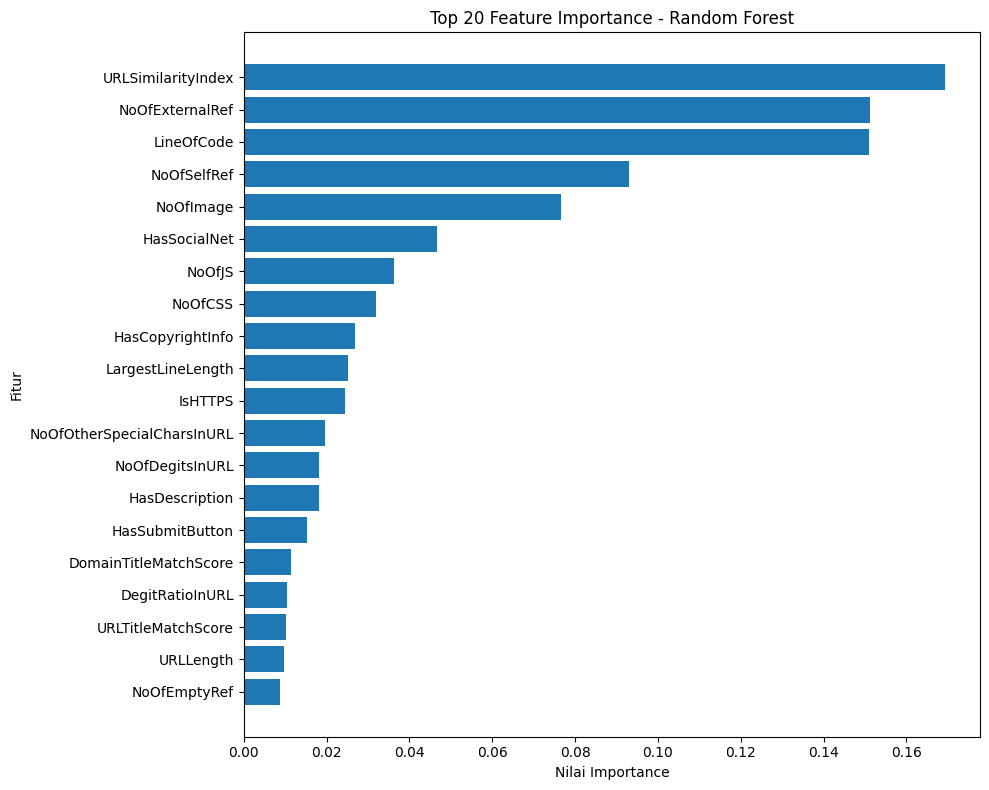

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\feature_importance_random_forest.png


In [28]:
top_importance_random_forest = importance_random_forest.head(20).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    top_importance_random_forest["fitur"],
    top_importance_random_forest["importance"]
)

plt.title("Top 20 Feature Importance - Random Forest")
plt.xlabel("Nilai Importance")
plt.ylabel("Fitur")
plt.tight_layout()

lokasi_gambar_importance_rf = direktori_gambar / "feature_importance_random_forest.png"
plt.savefig(lokasi_gambar_importance_rf, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar_importance_rf)

## Feature Importance XGBoost

In [29]:
importance_xgboost = pd.DataFrame({
    "fitur": X_train.columns,
    "importance": model_xgboost.feature_importances_
})

importance_xgboost = importance_xgboost.sort_values(
    by="importance",
    ascending=False
)

lokasi_importance_xgboost = direktori_output / "feature_importance_xgboost.csv"
importance_xgboost.to_csv(lokasi_importance_xgboost, index=False)

importance_xgboost.head(20)

,fitur,importance
3,URLSimilarityIndex,0.571717
49,NoOfExternalRef,0.324407
22,LineOfCode,0.037929
47,NoOfSelfRef,0.017948
19,NoOfOtherSpecialCharsInURL,0.014504
21,IsHTTPS,0.005778
8,NoOfSubDomain,0.005436
36,HasSocialNet,0.005322
32,HasDescription,0.003794
0,URLLength,0.002343


## Grafik Feature Importance XGBoost

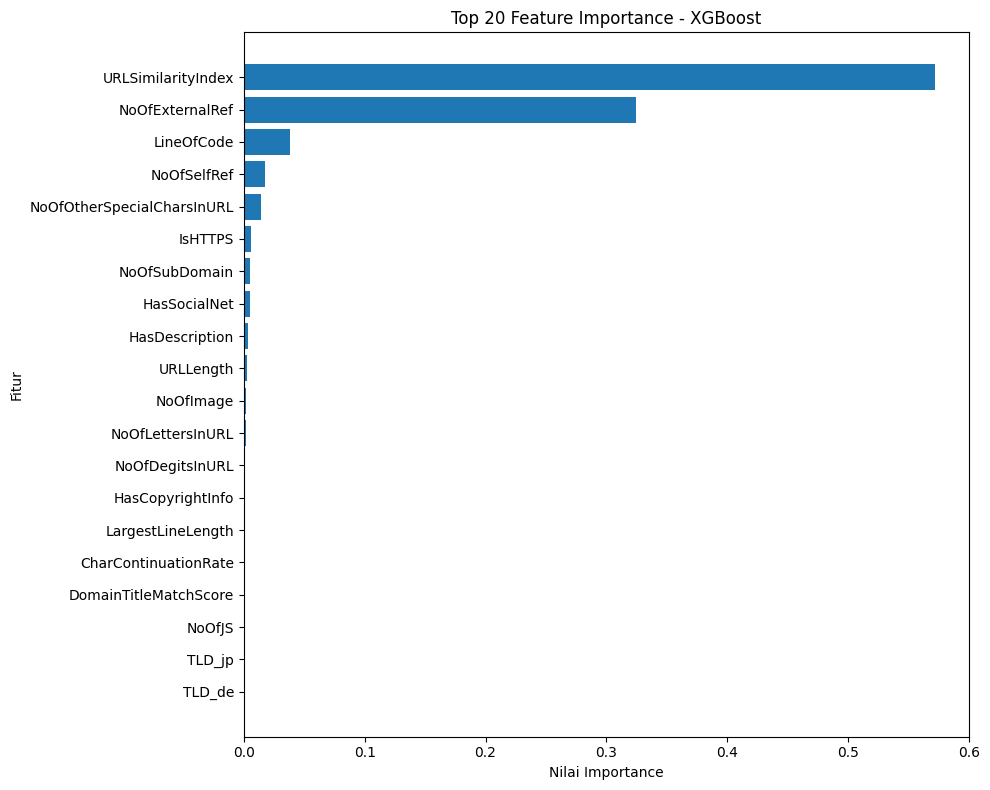

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\feature_importance_xgboost.png


In [30]:
top_importance_xgboost = importance_xgboost.head(20).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    top_importance_xgboost["fitur"],
    top_importance_xgboost["importance"]
)

plt.title("Top 20 Feature Importance - XGBoost")
plt.xlabel("Nilai Importance")
plt.ylabel("Fitur")
plt.tight_layout()

lokasi_gambar_importance_xgb = direktori_gambar / "feature_importance_xgboost.png"
plt.savefig(lokasi_gambar_importance_xgb, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar_importance_xgb)

## Koefisien Logistic Regression

In [31]:
koefisien_logistic = pd.DataFrame({
    "fitur": X_train_scaled.columns,
    "koefisien": model_logistic_regression.coef_[0]
})

koefisien_logistic["nilai_absolut"] = koefisien_logistic["koefisien"].abs()

koefisien_logistic = koefisien_logistic.sort_values(
    by="nilai_absolut",
    ascending=False
)

lokasi_koefisien_logistic = direktori_output / "koefisien_logistic_regression.csv"
koefisien_logistic.to_csv(lokasi_koefisien_logistic, index=False)

koefisien_logistic.head(20)

,fitur,koefisien,nilai_absolut
3,URLSimilarityIndex,-6.481450,6.481450
21,IsHTTPS,-3.995409,3.995409
20,SpacialCharRatioInURL,1.803781,1.803781
46,NoOfJS,-1.760977,1.760977
13,LetterRatioInURL,1.722629,1.722629
36,HasSocialNet,-1.574265,1.574265
8,NoOfSubDomain,-1.548037,1.548037
47,NoOfSelfRef,-1.313169,1.313169
15,DegitRatioInURL,1.273079,1.273079
44,NoOfImage,-1.241581,1.241581


## Menentukan Fitur Berisiko Terlalu Dominan

In [32]:
fitur_berisiko_dominan = [
    "URLSimilarityIndex",
    "TLDLegitimateProb",
    "URLCharProb",
    "DomainTitleMatchScore",
    "URLTitleMatchScore"
]

fitur_berisiko_dominan = [
    fitur for fitur in fitur_berisiko_dominan
    if fitur in X_train.columns
]

data_fitur_berisiko = pd.DataFrame({
    "fitur": fitur_berisiko_dominan,
    "alasan": [
        "Sangat kuat membedakan label dan perlu diuji ulang",
        "Bersifat probabilitas statistik TLD dan perlu hati-hati",
        "Bersifat probabilitas karakter URL dan perlu diuji ulang",
        "Skor kecocokan domain dan judul dapat terlalu membantu model",
        "Skor kecocokan URL dan judul dapat terlalu membantu model"
    ][:len(fitur_berisiko_dominan)]
})

lokasi_fitur_berisiko = direktori_output / "fitur_berisiko_dominan.csv"
data_fitur_berisiko.to_csv(lokasi_fitur_berisiko, index=False)

data_fitur_berisiko

,fitur,alasan
0,URLSimilarityIndex,Sangat kuat membedakan label dan perlu diuji u...
1,TLDLegitimateProb,Bersifat probabilitas statistik TLD dan perlu ...
2,URLCharProb,Bersifat probabilitas karakter URL dan perlu d...
3,DomainTitleMatchScore,Skor kecocokan domain dan judul dapat terlalu ...
4,URLTitleMatchScore,Skor kecocokan URL dan judul dapat terlalu mem...


## Membuat Dataset Tanpa Fitur Berisiko Dominan

In [33]:
X_train_tanpa_berisiko = X_train.drop(
    columns=fitur_berisiko_dominan,
    errors="ignore"
)

X_test_tanpa_berisiko = X_test.drop(
    columns=fitur_berisiko_dominan,
    errors="ignore"
)

print("Jumlah fitur awal:", X_train.shape[1])
print("Jumlah fitur tanpa fitur berisiko:", X_train_tanpa_berisiko.shape[1])
print("Fitur yang dihapus:", fitur_berisiko_dominan)

Jumlah fitur awal: 71
Jumlah fitur tanpa fitur berisiko: 66
Fitur yang dihapus: ['URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb', 'DomainTitleMatchScore', 'URLTitleMatchScore']


## Training Random Forest Tanpa Fitur Berisiko

Evaluasi Random Forest Tanpa Fitur Berisiko
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     26970
    Phishing       1.00      1.00      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



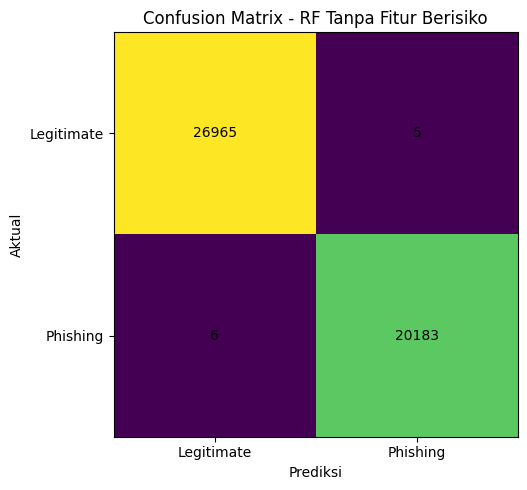

Confusion matrix disimpan di: C:\Users\ASUS\PHISHING\reports\figures\rf_tanpa_fitur_berisiko_confusion_matrix.png


In [34]:
model_rf_tanpa_berisiko = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_rf_tanpa_berisiko.fit(X_train_tanpa_berisiko, y_train)

hasil_rf_tanpa_berisiko, matriks_rf_tanpa_berisiko, laporan_rf_tanpa_berisiko = evaluasi_model(
    "Random Forest",
    "Tanpa Fitur Berisiko Dominan",
    model_rf_tanpa_berisiko,
    X_test_tanpa_berisiko,
    y_test,
    X_test_tanpa_berisiko.shape[1]
)

print("Evaluasi Random Forest Tanpa Fitur Berisiko")
print(laporan_rf_tanpa_berisiko)

simpan_confusion_matrix(
    "rf_tanpa_fitur_berisiko_confusion_matrix.png",
    "Confusion Matrix - RF Tanpa Fitur Berisiko",
    matriks_rf_tanpa_berisiko
)

## Menentukan Fitur URL-Only

In [35]:
fitur_url_dasar = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

fitur_tld_encoded = [
    fitur for fitur in X_train.columns
    if fitur.startswith("TLD_")
]

fitur_url_only = [
    fitur for fitur in fitur_url_dasar + fitur_tld_encoded
    if fitur in X_train.columns
]

X_train_url_only = X_train[fitur_url_only].copy()
X_test_url_only = X_test[fitur_url_only].copy()

print("Jumlah fitur URL-only:", len(fitur_url_only))
print(fitur_url_only)

Jumlah fitur URL-only: 39
['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'TLD_app', 'TLD_au', 'TLD_br', 'TLD_ca', 'TLD_co', 'TLD_com', 'TLD_de', 'TLD_dev', 'TLD_edu', 'TLD_fr', 'TLD_info', 'TLD_io', 'TLD_it', 'TLD_jp', 'TLD_lainnya', 'TLD_net', 'TLD_nl', 'TLD_org', 'TLD_ru', 'TLD_top', 'TLD_uk']


## Training Random Forest URL-Only

Evaluasi Random Forest URL-Only
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     26970
    Phishing       1.00      1.00      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



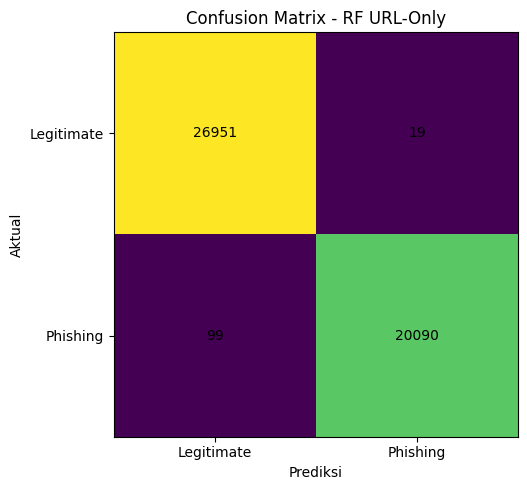

Confusion matrix disimpan di: C:\Users\ASUS\PHISHING\reports\figures\rf_url_only_confusion_matrix.png


In [36]:
model_rf_url_only = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_rf_url_only.fit(X_train_url_only, y_train)

hasil_rf_url_only, matriks_rf_url_only, laporan_rf_url_only = evaluasi_model(
    "Random Forest",
    "URL-Only",
    model_rf_url_only,
    X_test_url_only,
    y_test,
    X_test_url_only.shape[1]
)

print("Evaluasi Random Forest URL-Only")
print(laporan_rf_url_only)

simpan_confusion_matrix(
    "rf_url_only_confusion_matrix.png",
    "Confusion Matrix - RF URL-Only",
    matriks_rf_url_only
)

## Training XGBoost URL-Only

Evaluasi XGBoost URL-Only
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     26970
    Phishing       1.00      0.99      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



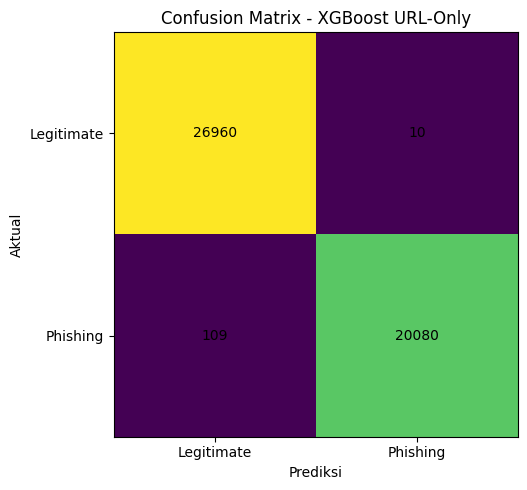

Confusion matrix disimpan di: C:\Users\ASUS\PHISHING\reports\figures\xgb_url_only_confusion_matrix.png


In [37]:
jumlah_legitimate = (y_train == 0).sum()
jumlah_phishing = (y_train == 1).sum()
bobot_phishing = jumlah_legitimate / jumlah_phishing

model_xgb_url_only = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=bobot_phishing,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model_xgb_url_only.fit(X_train_url_only, y_train)

hasil_xgb_url_only, matriks_xgb_url_only, laporan_xgb_url_only = evaluasi_model(
    "XGBoost",
    "URL-Only",
    model_xgb_url_only,
    X_test_url_only,
    y_test,
    X_test_url_only.shape[1]
)

print("Evaluasi XGBoost URL-Only")
print(laporan_xgb_url_only)

simpan_confusion_matrix(
    "xgb_url_only_confusion_matrix.png",
    "Confusion Matrix - XGBoost URL-Only",
    matriks_xgb_url_only
)

## Membandingkan Semua Skenario

In [38]:
hasil_semua_skenario = pd.DataFrame([
    hasil_logistic,
    hasil_random_forest,
    hasil_xgboost,
    hasil_rf_tanpa_berisiko,
    hasil_rf_url_only,
    hasil_xgb_url_only
])

kolom_metrik = [
    "accuracy",
    "precision_phishing",
    "recall_phishing",
    "f1_phishing",
    "roc_auc"
]

hasil_semua_skenario[kolom_metrik] = hasil_semua_skenario[kolom_metrik].round(4)

hasil_semua_skenario = hasil_semua_skenario.sort_values(
    by=["f1_phishing", "recall_phishing", "roc_auc", "jumlah_fitur"],
    ascending=[False, False, False, True]
)

hasil_semua_skenario

,nama_skenario,nama_model,jumlah_fitur,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc
1,Baseline Semua Fitur,Random Forest,71,1.0000,1.0000,1.0000,1.0000,1.0000
2,Baseline Semua Fitur,XGBoost,71,1.0000,1.0000,1.0000,1.0000,1.0000
0,Baseline Semua Fitur,Logistic Regression,71,0.9999,1.0000,0.9997,0.9999,1.0000
3,Tanpa Fitur Berisiko Dominan,Random Forest,66,0.9998,0.9998,0.9997,0.9997,1.0000
4,URL-Only,Random Forest,39,0.9975,0.9991,0.9951,0.9971,0.9988
5,URL-Only,XGBoost,39,0.9975,0.9995,0.9946,0.9970,0.9991


## Menyimpan Hasil Evaluasi Skenario

In [39]:
lokasi_hasil_skenario = direktori_output / "hasil_evaluasi_skenario_model.csv"
hasil_semua_skenario.to_csv(lokasi_hasil_skenario, index=False)

print("Hasil evaluasi skenario disimpan di:")
print(lokasi_hasil_skenario)

Hasil evaluasi skenario disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\hasil_evaluasi_skenario_model.csv


## Menyimpan Model Tambahan

In [40]:
lokasi_model_rf_tanpa_berisiko = direktori_models / "model_rf_tanpa_fitur_berisiko.pkl"
lokasi_model_rf_url_only = direktori_models / "model_rf_url_only.pkl"
lokasi_model_xgb_url_only = direktori_models / "model_xgb_url_only.pkl"

joblib.dump(model_rf_tanpa_berisiko, lokasi_model_rf_tanpa_berisiko)
joblib.dump(model_rf_url_only, lokasi_model_rf_url_only)
joblib.dump(model_xgb_url_only, lokasi_model_xgb_url_only)

print("Model RF tanpa fitur berisiko disimpan di:", lokasi_model_rf_tanpa_berisiko)
print("Model RF URL-only disimpan di:", lokasi_model_rf_url_only)
print("Model XGBoost URL-only disimpan di:", lokasi_model_xgb_url_only)

Model RF tanpa fitur berisiko disimpan di: C:\Users\ASUS\PHISHING\models\model_rf_tanpa_fitur_berisiko.pkl
Model RF URL-only disimpan di: C:\Users\ASUS\PHISHING\models\model_rf_url_only.pkl
Model XGBoost URL-only disimpan di: C:\Users\ASUS\PHISHING\models\model_xgb_url_only.pkl


## Menyimpan Daftar Fitur Model URL-Only

In [41]:
daftar_fitur_url_only = pd.DataFrame({
    "nomor": range(1, len(fitur_url_only) + 1),
    "nama_fitur": fitur_url_only
})

lokasi_fitur_url_only_csv = direktori_output / "daftar_fitur_url_only.csv"
daftar_fitur_url_only.to_csv(lokasi_fitur_url_only_csv, index=False)

lokasi_fitur_url_only_json = direktori_output / "daftar_fitur_url_only.json"

with open(lokasi_fitur_url_only_json, "w", encoding="utf-8") as file:
    json.dump(fitur_url_only, file, indent=4, ensure_ascii=False)

print("Daftar fitur URL-only disimpan di:")
print(lokasi_fitur_url_only_csv)
print(lokasi_fitur_url_only_json)

Daftar fitur URL-only disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\daftar_fitur_url_only.csv
C:\Users\ASUS\PHISHING\reports\outputs\daftar_fitur_url_only.json


## Memilih Kandidat Model Final

In [42]:
model_dataset_terbaik = hasil_semua_skenario.iloc[0]

hasil_url_only = hasil_semua_skenario[
    hasil_semua_skenario["nama_skenario"] == "URL-Only"
].sort_values(
    by=["f1_phishing", "recall_phishing", "roc_auc"],
    ascending=False
)

model_url_only_terbaik = hasil_url_only.iloc[0]

print("MODEL DATASET TERBAIK")
print("-" * 45)
print(model_dataset_terbaik)

print("\nMODEL URL-ONLY TERBAIK")
print("-" * 45)
print(model_url_only_terbaik)

MODEL DATASET TERBAIK
---------------------------------------------
nama_skenario         Baseline Semua Fitur
nama_model                   Random Forest
jumlah_fitur                            71
accuracy                               1.0
precision_phishing                     1.0
recall_phishing                        1.0
f1_phishing                            1.0
roc_auc                                1.0
Name: 1, dtype: object

MODEL URL-ONLY TERBAIK
---------------------------------------------
nama_skenario              URL-Only
nama_model            Random Forest
jumlah_fitur                     39
accuracy                     0.9975
precision_phishing           0.9991
recall_phishing              0.9951
f1_phishing                  0.9971
roc_auc                      0.9988
Name: 4, dtype: object


## Menyimpan Metadata Evaluasi Lanjutan

In [43]:
metadata_evaluasi_lanjutan = {
    "tujuan_step": "Menguji ulang model baseline, mengecek fitur dominan, dan membuat model URL-only.",
    "target": "target_phishing",
    "arti_target": {
        "1": "Phishing",
        "0": "Legitimate"
    },
    "fitur_berisiko_dominan": fitur_berisiko_dominan,
    "jumlah_fitur_semua": int(X_train.shape[1]),
    "jumlah_fitur_tanpa_berisiko": int(X_train_tanpa_berisiko.shape[1]),
    "jumlah_fitur_url_only": int(len(fitur_url_only)),
    "model_dataset_terbaik": {
        "nama_skenario": str(model_dataset_terbaik["nama_skenario"]),
        "nama_model": str(model_dataset_terbaik["nama_model"]),
        "f1_phishing": float(model_dataset_terbaik["f1_phishing"]),
        "recall_phishing": float(model_dataset_terbaik["recall_phishing"])
    },
    "model_url_only_terbaik": {
        "nama_skenario": str(model_url_only_terbaik["nama_skenario"]),
        "nama_model": str(model_url_only_terbaik["nama_model"]),
        "f1_phishing": float(model_url_only_terbaik["f1_phishing"]),
        "recall_phishing": float(model_url_only_terbaik["recall_phishing"])
    },
    "catatan": "Model semua fitur cocok untuk evaluasi dataset. Model URL-only lebih realistis untuk aplikasi prediksi dari input URL."
}

lokasi_metadata_evaluasi_lanjutan = direktori_output / "metadata_evaluasi_lanjutan.json"

with open(lokasi_metadata_evaluasi_lanjutan, "w", encoding="utf-8") as file:
    json.dump(metadata_evaluasi_lanjutan, file, indent=4, ensure_ascii=False)

print("Metadata evaluasi lanjutan disimpan di:")
print(lokasi_metadata_evaluasi_lanjutan)

Metadata evaluasi lanjutan disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\metadata_evaluasi_lanjutan.json


## Ringkasan Akhir

In [44]:
print("RINGKASAN STEP 6")
print("-" * 45)
print("Jumlah fitur semua:", X_train.shape[1])
print("Jumlah fitur tanpa fitur berisiko:", X_train_tanpa_berisiko.shape[1])
print("Jumlah fitur URL-only:", len(fitur_url_only))

print("\nFitur berisiko dominan yang diuji ulang:")
for fitur in fitur_berisiko_dominan:
    print("-", fitur)

print("\nHasil evaluasi semua skenario:")
print(hasil_semua_skenario)

print("\nModel dataset terbaik:")
print(model_dataset_terbaik["nama_skenario"], "-", model_dataset_terbaik["nama_model"])

print("\nModel URL-only terbaik:")
print(model_url_only_terbaik["nama_skenario"], "-", model_url_only_terbaik["nama_model"])

print("\nFile penting yang sudah disimpan:")
print(lokasi_hasil_skenario)
print(lokasi_model_rf_tanpa_berisiko)
print(lokasi_model_rf_url_only)
print(lokasi_model_xgb_url_only)
print(lokasi_metadata_evaluasi_lanjutan)

RINGKASAN STEP 6
---------------------------------------------
Jumlah fitur semua: 71
Jumlah fitur tanpa fitur berisiko: 66
Jumlah fitur URL-only: 39

Fitur berisiko dominan yang diuji ulang:
- URLSimilarityIndex
- TLDLegitimateProb
- URLCharProb
- DomainTitleMatchScore
- URLTitleMatchScore

Hasil evaluasi semua skenario:
                  nama_skenario           nama_model  jumlah_fitur  accuracy  \
1          Baseline Semua Fitur        Random Forest            71    1.0000   
2          Baseline Semua Fitur              XGBoost            71    1.0000   
0          Baseline Semua Fitur  Logistic Regression            71    0.9999   
3  Tanpa Fitur Berisiko Dominan        Random Forest            66    0.9998   
4                      URL-Only        Random Forest            39    0.9975   
5                      URL-Only              XGBoost            39    0.9975   

   precision_phishing  recall_phishing  f1_phishing  roc_auc  
1              1.0000           1.0000       1.0000 